In [ ]:
import os
from google.colab import drive
import zipfile
import cv2, json
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# from google.colab import drive
drive.mount("/content/drive")

# import os
workdir = "/content/tbp_project"
os.makedirs(workdir, exist_ok=True)
print("Workdir:", workdir)


Mounted at /content/drive
Workdir: /content/tbp_project


In [ ]:

zip_path = "/content/drive/MyDrive/TBP-To_Share/PartialBodyDataset-20240221T171158Z-001.zip"
extract_root = f"{workdir}/raw_extracted"
os.makedirs(extract_root, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_root)

print("Extracted to:", extract_root)


Extracted to: /content/tbp_project/raw_extracted


In [ ]:
# import os

BASE = "/content/tbp_project/raw_extracted/PartialBodyDataset"
IMG_DIR  = f"{BASE}/Data"
MASK_DIR = f"{BASE}/GroundTruth"
META_DIR = f"{BASE}/Metadata"

OUT_DIR = "/content/tbp_project/output/realistic"
os.makedirs(OUT_DIR, exist_ok=True)

print("IMG_DIR :", IMG_DIR)
print("MASK_DIR:", MASK_DIR)
print("META_DIR:", META_DIR)
print("OUT_DIR :", OUT_DIR)


IMG_DIR : /content/tbp_project/raw_extracted/PartialBodyDataset/Data
MASK_DIR: /content/tbp_project/raw_extracted/PartialBodyDataset/GroundTruth
META_DIR: /content/tbp_project/raw_extracted/PartialBodyDataset/Metadata
OUT_DIR : /content/tbp_project/output/realistic


In [ ]:
# import cv2, json

sample_id = "001_WMale"
img_path  = f"{IMG_DIR}/model_{sample_id}.png"
mask_path = f"{MASK_DIR}/mask_{sample_id}.png"
json_path = f"{META_DIR}/{sample_id}.json"

img  = cv2.imread(img_path, cv2.IMREAD_COLOR)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

with open(json_path, "r") as f:
    meta = json.load(f)

print("Loaded:", img_path)
print("Mask  :", mask_path)
print("JSON keys:", list(meta.keys())[:10])
print("Image shape:", img.shape, "Mask shape:", mask.shape)


Loaded: /content/tbp_project/raw_extracted/PartialBodyDataset/Data/model_001_WMale.png
Mask  : /content/tbp_project/raw_extracted/PartialBodyDataset/GroundTruth/mask_001_WMale.png
JSON keys: ['NumberOfLesions', 'Lesions', 'ModelName', 'Index', 'Filename', 'Count', 'CameraAngle', 'Height', 'Width']
Image shape: (2048, 1024, 3) Mask shape: (2048, 1024)


In [ ]:
# this function was an attempt to add things to the image to make it look more realistic
#doesnt really work great

def make_more_realistic(image_bgr: np.ndarray, mask_gray: np.ndarray, seed: int = 0) -> np.ndarray:
    rng = np.random.default_rng(seed)
    img = image_bgr.copy()
    mask = (mask_gray > 0).astype(np.uint8)

    alpha = float(rng.uniform(0.98, 1.05))   # smaller contrast range
    beta  = float(rng.uniform(-6, 6))        # smaller brightness range
    img = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

    # tiny white balance shift
    scales = rng.uniform(0.99, 1.01, size=(3,))
    img = np.clip(img.astype(np.float32) * scales[None, None, :], 0, 255).astype(np.uint8)

    # subtle sensor noise
    noise = rng.normal(0, 2.0, size=img.shape).astype(np.float32)
    img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

    # trying to add skin texture (pores) - subtle, band-pass noise
    # Create a gray texture field, band-pass it, then add lightly to the image luminance
    h, w = img.shape[:2]
    tex = rng.normal(0, 1.0, size=(h, w)).astype(np.float32)
    # band-pass: blur low-freq and subtract -> "high-ish" texture
    low = cv2.GaussianBlur(tex, (0, 0), sigmaX=12.0)
    high = tex - low
    high = cv2.GaussianBlur(high, (0, 0), sigmaX=1.5)  # smooth tiny speckles

    # normalize and scale
    high = high / (np.std(high) + 1e-8)
    pore_strength = float(rng.uniform(1.0, 2.5))  # keep small
    pore_field = high * pore_strength

    # apply pores mostly to skin midtones (avoid deep shadows/highlights)
    img_f = img.astype(np.float32)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
    skin_weight = np.clip(1.0 - 4.0 * (gray - 0.55) ** 2, 0, 1)
    skin_weight = cv2.GaussianBlur(skin_weight, (0, 0), sigmaX=3.0)

    for c in range(3):
        img_f[:, :, c] = np.clip(img_f[:, :, c] + pore_field * skin_weight, 0, 255)

    img = img_f.astype(np.uint8)
    out = img.astype(np.float32)

    # Smooth field for subtle pigment variation inside lesions
    ltex = rng.normal(0, 1.0, size=(h, w)).astype(np.float32)
    ltex = cv2.GaussianBlur(ltex, (0, 0), sigmaX=4.0)
    ltex = ltex / (np.std(ltex) + 1e-8)

    # small multiplicative variation around 1.0
    # (this keeps lesion’s mean color similar, just adds realism)
    amp = float(rng.uniform(0.03, 0.08))
    lesion_mult = 1.0 + amp * ltex

    for c in range(3):
        out[:, :, c] = np.where(mask == 1, out[:, :, c] * lesion_mult, out[:, :, c])

    # tiny desaturation inside lesions
    if rng.random() < 0.7:
        hsv = cv2.cvtColor(np.clip(out, 0, 255).astype(np.uint8), cv2.COLOR_BGR2HSV).astype(np.float32)
        sat_scale = float(rng.uniform(0.92, 0.98))
        hsv[:, :, 1] = np.where(mask == 1, hsv[:, :, 1] * sat_scale, hsv[:, :, 1])
        out = cv2.cvtColor(np.clip(hsv, 0, 255).astype(np.uint8), cv2.COLOR_HSV2BGR).astype(np.float32)

    # very subtle feather seam at lesion boundary (very subtle)
    kernel = np.ones((5, 5), np.uint8)
    edge = cv2.morphologyEx(mask, cv2.MORPH_GRADIENT, kernel)
    for c in range(3):
        out[:, :, c] = np.where(edge == 1, out[:, :, c] * 0.99 + img[:, :, c] * 0.01, out[:, :, c])

    return np.clip(out, 0, 255).astype(np.uint8)


In [ ]:
OUT_DIR = "/content/tbp_project/output/realistic"
os.makedirs(OUT_DIR, exist_ok=True)

sample_id = "001_WMale"

out_img = make_more_realistic(img, mask, seed=42)

out_img_path  = f"{OUT_DIR}/realistic_model_{sample_id}.png"
out_mask_path = f"{OUT_DIR}/mask_{sample_id}.png"  # unchanged mask

cv2.imwrite(out_img_path, out_img)
cv2.imwrite(out_mask_path, mask)

print("Saved realistic image:", out_img_path)
print("Saved mask (unchanged):", out_mask_path)


Saved realistic image: /content/tbp_project/output/realistic/realistic_model_001_WMale.png
Saved mask (unchanged): /content/tbp_project/output/realistic/mask_001_WMale.png


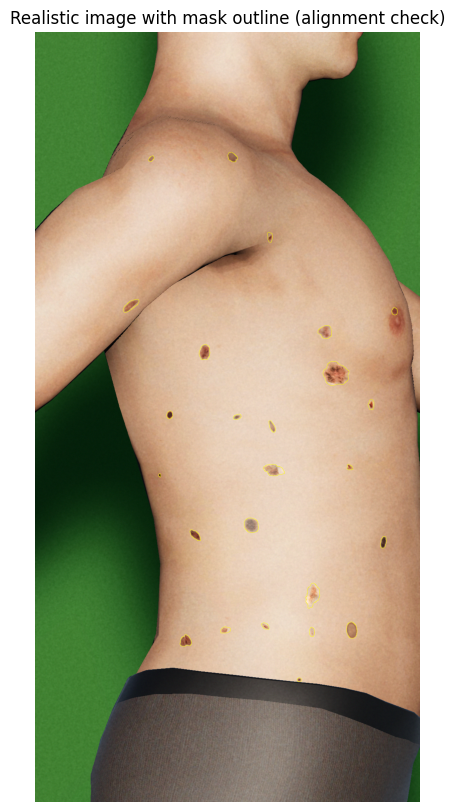

In [ ]:
# import matplotlib.pyplot as plt
# import cv2
# import numpy as np

mask_bin = (mask > 0).astype(np.uint8)
edges = cv2.Canny(mask_bin * 255, 50, 150)

overlay = out_img.copy()
overlay[edges > 0] = (0, 255, 255)  # yellow outline

plt.figure(figsize=(6, 10))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Realistic image with mask outline (alignment check)")
plt.show()


In [ ]:

mask_path = "/content/tbp_project/raw_extracted/PartialBodyDataset/GroundTruth/mask_001_WMale.png"
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
mask_bin = (mask > 0).astype(np.uint8)

num_labels, labels = cv2.connectedComponents(mask_bin)
print("Connected components (including background):", num_labels)
print("Estimated lesion instances:", num_labels - 1)


Connected components (including background): 26
Estimated lesion instances: 25


In [ ]:
# #Attempt 2
# reads dataset structure (Data/, GroundTruth/, Metadata/)

# converts mask that we are given into instance masks via connected components

# trains maskrcnn_resnet50_fpn, mask rcnn model

# runs quick evaluation (mean mask IoU)
# Mean mask ioU - measures the average overlap between predicted segmentation masks and ground truth masks across all lesions

# exports predicted masks + JSON for your pipeline/

In [ ]:
!pip -q install torch torchvision opencv-python pycocotools

import os, json, re, random
import numpy as np
import cv2

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.transforms import functional as F
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor


In [ ]:
BASE = "/content/tbp_project/raw_extracted/PartialBodyDataset"
IMG_DIR  = f"{BASE}/Data"
MASK_DIR = f"{BASE}/GroundTruth"
META_DIR = f"{BASE}/Metadata"

print("IMG_DIR :", IMG_DIR)
print("MASK_DIR:", MASK_DIR)
print("META_DIR:", META_DIR)
print("Example:", os.path.join(IMG_DIR, "model_001_WMale.png"))


IMG_DIR : /content/tbp_project/raw_extracted/PartialBodyDataset/Data
MASK_DIR: /content/tbp_project/raw_extracted/PartialBodyDataset/GroundTruth
META_DIR: /content/tbp_project/raw_extracted/PartialBodyDataset/Metadata
Example: /content/tbp_project/raw_extracted/PartialBodyDataset/Data/model_001_WMale.png


In [ ]:
def sample_id_from_model_filename(fn: str) -> str:
    # model_001_WMale.png -> 001_WMale
    b = os.path.splitext(fn)[0]
    return re.sub(r"^model_", "", b)

def mask_to_instances(mask_gray: np.ndarray):
    """Return instance_masks (N,H,W) uint8 0/1 and boxes (N,4) float32."""
    mask_bin = (mask_gray > 0).astype(np.uint8)
    num_labels, labels = cv2.connectedComponents(mask_bin)

    instance_masks = []
    boxes = []
    areas = []

    # label 0 is background
    for lab in range(1, num_labels):
        m = (labels == lab).astype(np.uint8)
        ys, xs = np.where(m > 0)
        if len(xs) == 0:
            continue

        x1, y1, x2, y2 = xs.min(), ys.min(), xs.max(), ys.max()

        # Filter tiny specks (tune if needed)
        area = int(m.sum())
        if area < 20:
            continue

        instance_masks.append(m)
        boxes.append([x1, y1, x2, y2])
        areas.append(area)

    if len(instance_masks) == 0:
        # handle edge case: no lesions
        instance_masks = np.zeros((0, mask_gray.shape[0], mask_gray.shape[1]), dtype=np.uint8)
        boxes = np.zeros((0, 4), dtype=np.float32)
        areas = np.zeros((0,), dtype=np.float32)
    else:
        instance_masks = np.stack(instance_masks, axis=0)  # N,H,W
        boxes = np.array(boxes, dtype=np.float32)
        areas = np.array(areas, dtype=np.float32)

    return instance_masks, boxes, areas


In [ ]:
class TBPInstanceDataset(Dataset):
    def __init__(self, img_dir, mask_dir, meta_dir, sample_ids, train=True):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.meta_dir = meta_dir
        self.sample_ids = sample_ids
        self.train = train

    def __len__(self):
        return len(self.sample_ids)

    def __getitem__(self, idx):
        sid = self.sample_ids[idx]
        img_path  = os.path.join(self.img_dir,  f"model_{sid}.png")
        mask_path = os.path.join(self.mask_dir, f"mask_{sid}.png")
        meta_path = os.path.join(self.meta_dir, f"{sid}.json")

        img_bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)
        mask_g  = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if img_bgr is None or mask_g is None:
            raise FileNotFoundError(f"Missing files for {sid}")

        # BGR->RGB
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        instance_masks, boxes, areas = mask_to_instances(mask_g)
        num_inst = instance_masks.shape[0]

        # Target dict for torchvision Mask R-CNN
        target = {
            "boxes": torch.as_tensor(boxes, dtype=torch.float32),
            "labels": torch.ones((num_inst,), dtype=torch.int64),  # 1 class: lesion
            "masks": torch.as_tensor(instance_masks, dtype=torch.uint8),
            "image_id": torch.tensor([idx], dtype=torch.int64),
            "area": torch.as_tensor(areas, dtype=torch.float32),
            "iscrowd": torch.zeros((num_inst,), dtype=torch.int64),
        }



        if self.train:
            if random.random() < 0.5:
                img_rgb = np.ascontiguousarray(img_rgb[:, ::-1, :])

                # flip masks (Tensor) safely
                target["masks"] = torch.flip(target["masks"], dims=[2])  # flip width dimension

                # flip boxes
                x1y1x2y2 = target["boxes"].clone()
                W = img_rgb.shape[1]
                target["boxes"][:, 0] = W - x1y1x2y2[:, 2]
                target["boxes"][:, 2] = W - x1y1x2y2[:, 0]

        # To tensor [0,1]
        img_tensor = F.to_tensor(img_rgb)  # float32 CxHxW

        return img_tensor, target

def collate_fn(batch):
    return tuple(zip(*batch))


In [ ]:
# import os, re

def sid_from_model_file(fn):
    # model_416_WMale(1).png -> 416_WMale(1)
    return re.sub(r"^model_", "", os.path.splitext(fn)[0])

model_files = [f for f in os.listdir(IMG_DIR) if f.startswith("model_") and f.lower().endswith(".png")]
mask_files  = set([f for f in os.listdir(MASK_DIR) if f.startswith("mask_") and f.lower().endswith(".png")])
json_files  = set([f for f in os.listdir(META_DIR) if f.lower().endswith(".json")])

valid_ids = []
missing = {"mask": 0, "json": 0}

for mf in sorted(model_files):
    sid = sid_from_model_file(mf)

    expected_mask = f"mask_{sid}.png"
    expected_json = f"{sid}.json"

    ok_mask = expected_mask in mask_files
    ok_json = expected_json in json_files

    if ok_mask and ok_json:
        valid_ids.append(sid)
    else:
        if not ok_mask: missing["mask"] += 1
        if not ok_json: missing["json"] += 1

print("Total model files:", len(model_files))
print("Valid triplets   :", len(valid_ids))
print("Missing masks    :", missing["mask"])
print("Missing json     :", missing["json"])
print("Example valid id :", valid_ids[0] if valid_ids else None)


Total model files: 499
Valid triplets   : 498
Missing masks    : 1
Missing json     : 1
Example valid id : 001_WMale


In [ ]:
all_model_files = sorted([f for f in os.listdir(IMG_DIR) if f.lower().endswith(".png") and f.startswith("model_")])
all_ids = [sample_id_from_model_filename(f) for f in all_model_files]

random.seed(42)
random.shuffle(valid_ids)

n = len(valid_ids)
n_test = max(1, int(0.2 * n))
test_ids = valid_ids[:n_test]
train_ids = valid_ids[n_test:]

print("Total valid:", n, "Train:", len(train_ids), "Test:", len(test_ids))

Total valid: 498 Train: 399 Test: 99


In [ ]:

def get_model(num_classes=2):
    # num_classes includes background
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")

    # Box head
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # Mask head
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden = 256
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden, num_classes)

    return model


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

train_ds = TBPInstanceDataset(IMG_DIR, MASK_DIR, META_DIR, train_ids, train=True)
test_ds  = TBPInstanceDataset(IMG_DIR, MASK_DIR, META_DIR, test_ids,  train=False)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=0, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  batch_size=1, shuffle=False, num_workers=0, collate_fn=collate_fn)

model = get_model(num_classes=2).to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(params, lr=1e-4, weight_decay=1e-4)

def train_one_epoch(model, loader):
    model.train()
    total = 0.0
    for images, targets in loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total += float(loss.item())
    return total / max(1, len(loader))

for epoch in range(3):  # start small
    avg_loss = train_one_epoch(model, train_loader)
    print(f"Epoch {epoch+1}: loss={avg_loss:.4f}")


Device: cuda
Epoch 1: loss=0.6231
Epoch 2: loss=0.5062
Epoch 3: loss=0.4509


In [ ]:
import numpy as np
import torch

def mask_iou(a: np.ndarray, b: np.ndarray) -> float:
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return float(inter) / float(union + 1e-8)

@torch.no_grad()
def eval_mean_instance_iou(model, loader, score_thresh=0.5):
    model.eval()
    ious = []

    for images, targets in loader:
        img = images[0].to(device)

        gt_masks = targets[0]["masks"].cpu().numpy().astype(bool)  # (N,H,W)

        pred = model([img])[0]

        keep = pred["scores"].detach().cpu().numpy() >= score_thresh
        pred_masks = pred["masks"].detach().cpu().numpy()[keep, 0] > 0.5  # (M,H,W)

        for g in gt_masks:
            if pred_masks.shape[0] == 0:
                ious.append(0.0)
                continue

            best = max(mask_iou(g, p) for p in pred_masks)
            ious.append(best)

    return float(np.mean(ious)) if len(ious) else 0.0


In [ ]:
mean_iou = eval_mean_instance_iou(model, test_loader, score_thresh=0.5)
print("Mean best-IoU per GT instance:", mean_iou)


Mean best-IoU per GT instance: 0.828093387795804
